NOTE: The "Check" function is used to check is any problems are found within your dataframe

In [50]:
import pandas as pd
import numpy as np
from plotnine import*
import calendar

In [51]:
df_airquality = pd.read_csv('Air_quality_analytics.csv')

In [52]:
# Converting date column as a date format

df_airquality['date'] = pd.to_datetime(df_airquality['date'], format = "%Y-%m-%d")
df_airquality.info()
df_airquality.head()

<class 'pandas.DataFrame'>
RangeIndex: 87084 entries, 0 to 87083
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   _id              87084 non-null  int64         
 1   date             87084 non-null  datetime64[us]
 2   site             87084 non-null  str           
 3   parameter        87084 non-null  str           
 4   index_value      87084 non-null  int64         
 5   description      87084 non-null  str           
 6   health_advisory  7573 non-null   str           
 7   health_effects   7573 non-null   str           
dtypes: datetime64[us](1), int64(2), str(5)
memory usage: 5.3 MB


,_id,date,site,parameter,index_value,description,health_advisory,health_effects
0,1,2016-01-01,Lawrenceville,PM25B,25,Good,NaN,NaN
1,2,2016-01-01,Flag Plaza,CO,0,Good,NaN,NaN
2,3,2016-01-01,Harrison Township,OZONE,31,Good,NaN,NaN
3,4,2016-01-01,Avalon,SO2,10,Good,NaN,NaN
4,5,2016-01-01,Lincoln,PM25,35,Good,NaN,NaN


In [53]:
# Getting rid of additional duplicates

df_airquality = df_airquality[df_airquality['parameter'] != 'PM25(2)']
df_airquality = df_airquality[df_airquality['site'] != 'Lawrenceville 2']
df_airquality = df_airquality[df_airquality['site'] != 'Liberty 2']

In [54]:
# Deleting partial year 2026

df_airquality = df_airquality[df_airquality['date'].dt.year != 2026]

In [55]:
# Checking for Duplicates

n_rows = len(df_airquality)
n_unique = df_airquality[['site', 'parameter', 'date']].drop_duplicates().shape[0]

print(n_rows, n_unique)
print(n_rows == n_unique)

# No Duplicates Confirmed

66304 66304
True


In [56]:
# Adding month & month name column

df_airquality['month'] = df_airquality['date'].dt.month
df_airquality['month_name'] = df_airquality['month'].apply(lambda x: calendar.month_name[x])

In [57]:
# Reference
df_airquality.info()
df_airquality.head()

<class 'pandas.DataFrame'>
Index: 66304 entries, 0 to 80730
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   _id              66304 non-null  int64         
 1   date             66304 non-null  datetime64[us]
 2   site             66304 non-null  str           
 3   parameter        66304 non-null  str           
 4   index_value      66304 non-null  int64         
 5   description      66304 non-null  str           
 6   health_advisory  5313 non-null   str           
 7   health_effects   5313 non-null   str           
 8   month            66304 non-null  int32         
 9   month_name       66304 non-null  str           
dtypes: datetime64[us](1), int32(1), int64(2), str(6)
memory usage: 5.3 MB


,_id,date,site,parameter,index_value,description,health_advisory,health_effects,month,month_name
0,1,2016-01-01,Lawrenceville,PM25B,25,Good,NaN,NaN,1,January
1,2,2016-01-01,Flag Plaza,CO,0,Good,NaN,NaN,1,January
2,3,2016-01-01,Harrison Township,OZONE,31,Good,NaN,NaN,1,January
3,4,2016-01-01,Avalon,SO2,10,Good,NaN,NaN,1,January
4,5,2016-01-01,Lincoln,PM25,35,Good,NaN,NaN,1,January


Now we must start to group pollutants together, to make it easier for identifying domains of pollutants


# Group by Pollutant and Season and take the Mean

In [58]:
# Grouping by Pollutant

pollutant_dictionary = {
    'PM25':  ['PM25', 'PM25B', 'PM25T', 'PM25_640'],
    'PM10':  ['PM10', 'PM10B', 'PM10_640'],
    'CO':    ['CO'],
    'Ozone': ['OZONE'],
    'SO2':   ['SO2'],
    'NO2':   ['NO2', 'NO2_500', 'NO2_200'],
}

In [59]:
code_to_group = {code: group
                 for group, codes in pollutant_dictionary.items()
                 for code in codes}

In [60]:
# New column to implement original pollutants (which include all variants overtime)
 
df_airquality['pollutant_dic'] = df_airquality['parameter'].map(code_to_group)

In [61]:
# Grouping to site, and original pollutant, in order of date

daily = (df_airquality.groupby(['site', 'date', 'pollutant_dic'])['index_value']
           .mean().reset_index())

In [62]:
# Average by pollutant by day (no matter the location)
# Set the trend of those pollutants

Avg_PM25 = daily[daily['pollutant_dic'] == 'PM25']
Monthly_PM25_Trend = Avg_PM25.set_index('date')['index_value'].resample('MS').mean()

Avg_PM10 = daily[daily['pollutant_dic'] == 'PM10']
Monthly_PM10_Trend = Avg_PM10.set_index('date')['index_value'].resample('MS').mean()

Avg_CO = daily[daily['pollutant_dic'] == 'CO']
Monthly_CO_Trend = Avg_CO.set_index('date')['index_value'].resample('MS').mean()

Avg_Ozone = daily[daily['pollutant_dic'] == 'Ozone']
Monthly_Ozone_Trend = Avg_Ozone.set_index('date')['index_value'].resample('MS').mean()

Avg_SO2 = daily[daily['pollutant_dic'] == 'SO2']
Monthly_SO2_Trend = Avg_SO2.set_index('date')['index_value'].resample('MS').mean()

Avg_NO2 = daily[daily['pollutant_dic'] == 'NO2']
Monthly_NO2_Trend = Avg_NO2.set_index('date')['index_value'].resample('MS').mean()


In [63]:
# Reference 
Avg_PM25

,site,date,pollutant_dic,index_value
148,Avalon,2016-05-28,PM25,68.0
150,Avalon,2016-05-29,PM25,67.0
152,Avalon,2016-05-30,PM25,56.0
154,Avalon,2016-05-31,PM25,50.0
156,Avalon,2016-06-01,PM25,54.0
...,...,...,...,...
65906,South Fayette,2025-12-27,PM25,33.0
65908,South Fayette,2025-12-28,PM25,53.0
65910,South Fayette,2025-12-29,PM25,19.0
65912,South Fayette,2025-12-30,PM25,22.0


Now that we have calculated the averages of each pollutant, we can now plot them year-by-year, and see the trends of the AQI (x) within each month (y). Aditionally, there is a legend to color each season (December is winter, but it's a seperate legend from winter (which is blue)). I'll be using plotnine for providing the visuals.
# Plotting the Averages

In [64]:
# Reseting the dataframes in order to make plots

plot_df_PM25 = Monthly_PM25_Trend.reset_index()
plot_df_PM10 = Monthly_PM10_Trend.reset_index()
plot_df_CO = Monthly_CO_Trend.reset_index()
plot_df_Ozone = Monthly_Ozone_Trend.reset_index()
plot_df_SO2 = Monthly_SO2_Trend.reset_index()
plot_df_NO2 = Monthly_NO2_Trend.reset_index()

In [65]:
# Adding, year, and month to the dataframe in order to plot

# PM25

plot_df_PM25.columns = ['date', 'index_value']
plot_df_PM25['year'] = plot_df_PM25['date'].dt.year
plot_df_PM25['month'] = plot_df_PM25['date'].dt.month

#PM10
plot_df_PM10.columns = ['date', 'index_value']
plot_df_PM10['year'] = plot_df_PM10['date'].dt.year
plot_df_PM10['month'] = plot_df_PM10['date'].dt.month

#CO
plot_df_CO.columns = ['date', 'index_value']
plot_df_CO['year'] = plot_df_CO['date'].dt.year
plot_df_CO['month'] = plot_df_CO['date'].dt.month

#Ozone
plot_df_Ozone.columns = ['date', 'index_value']
plot_df_Ozone['year'] = plot_df_Ozone['date'].dt.year
plot_df_Ozone['month'] = plot_df_Ozone['date'].dt.month

#SO2
plot_df_SO2.columns = ['date', 'index_value']
plot_df_SO2['year'] = plot_df_SO2['date'].dt.year
plot_df_SO2['month'] = plot_df_SO2['date'].dt.month

#NO2
plot_df_NO2.columns = ['date', 'index_value']
plot_df_NO2['year'] = plot_df_NO2['date'].dt.year
plot_df_NO2['month'] = plot_df_NO2['date'].dt.month

In [66]:
# Adding season to the dataframes

season = {1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall', 12: 'Winter_Dec'}

plot_df_PM25['season'] = plot_df_PM25['month'].map(season)
plot_df_PM10['season'] = plot_df_PM10['month'].map(season)
plot_df_CO['season'] = plot_df_CO['month'].map(season)
plot_df_Ozone['season'] = plot_df_Ozone['month'].map(season)
plot_df_SO2['season'] = plot_df_SO2['month'].map(season)
plot_df_NO2['season'] = plot_df_NO2['month'].map(season)

In [67]:
#Reference
plot_df_PM25

,date,index_value,year,month,season
0,2016-01-01,46.655914,2016,1,Winter
1,2016-02-01,39.348837,2016,2,Winter
2,2016-03-01,43.488636,2016,3,Spring
3,2016-04-01,41.193182,2016,4,Spring
4,2016-05-01,47.567010,2016,5,Spring
...,...,...,...,...,...
115,2025-08-01,44.698925,2025,8,Summer
116,2025-09-01,42.883333,2025,9,Fall
117,2025-10-01,26.300971,2025,10,Fall
118,2025-11-01,36.854369,2025,11,Fall


# Visual trend of Pollutants over 10 years (GROUPED)

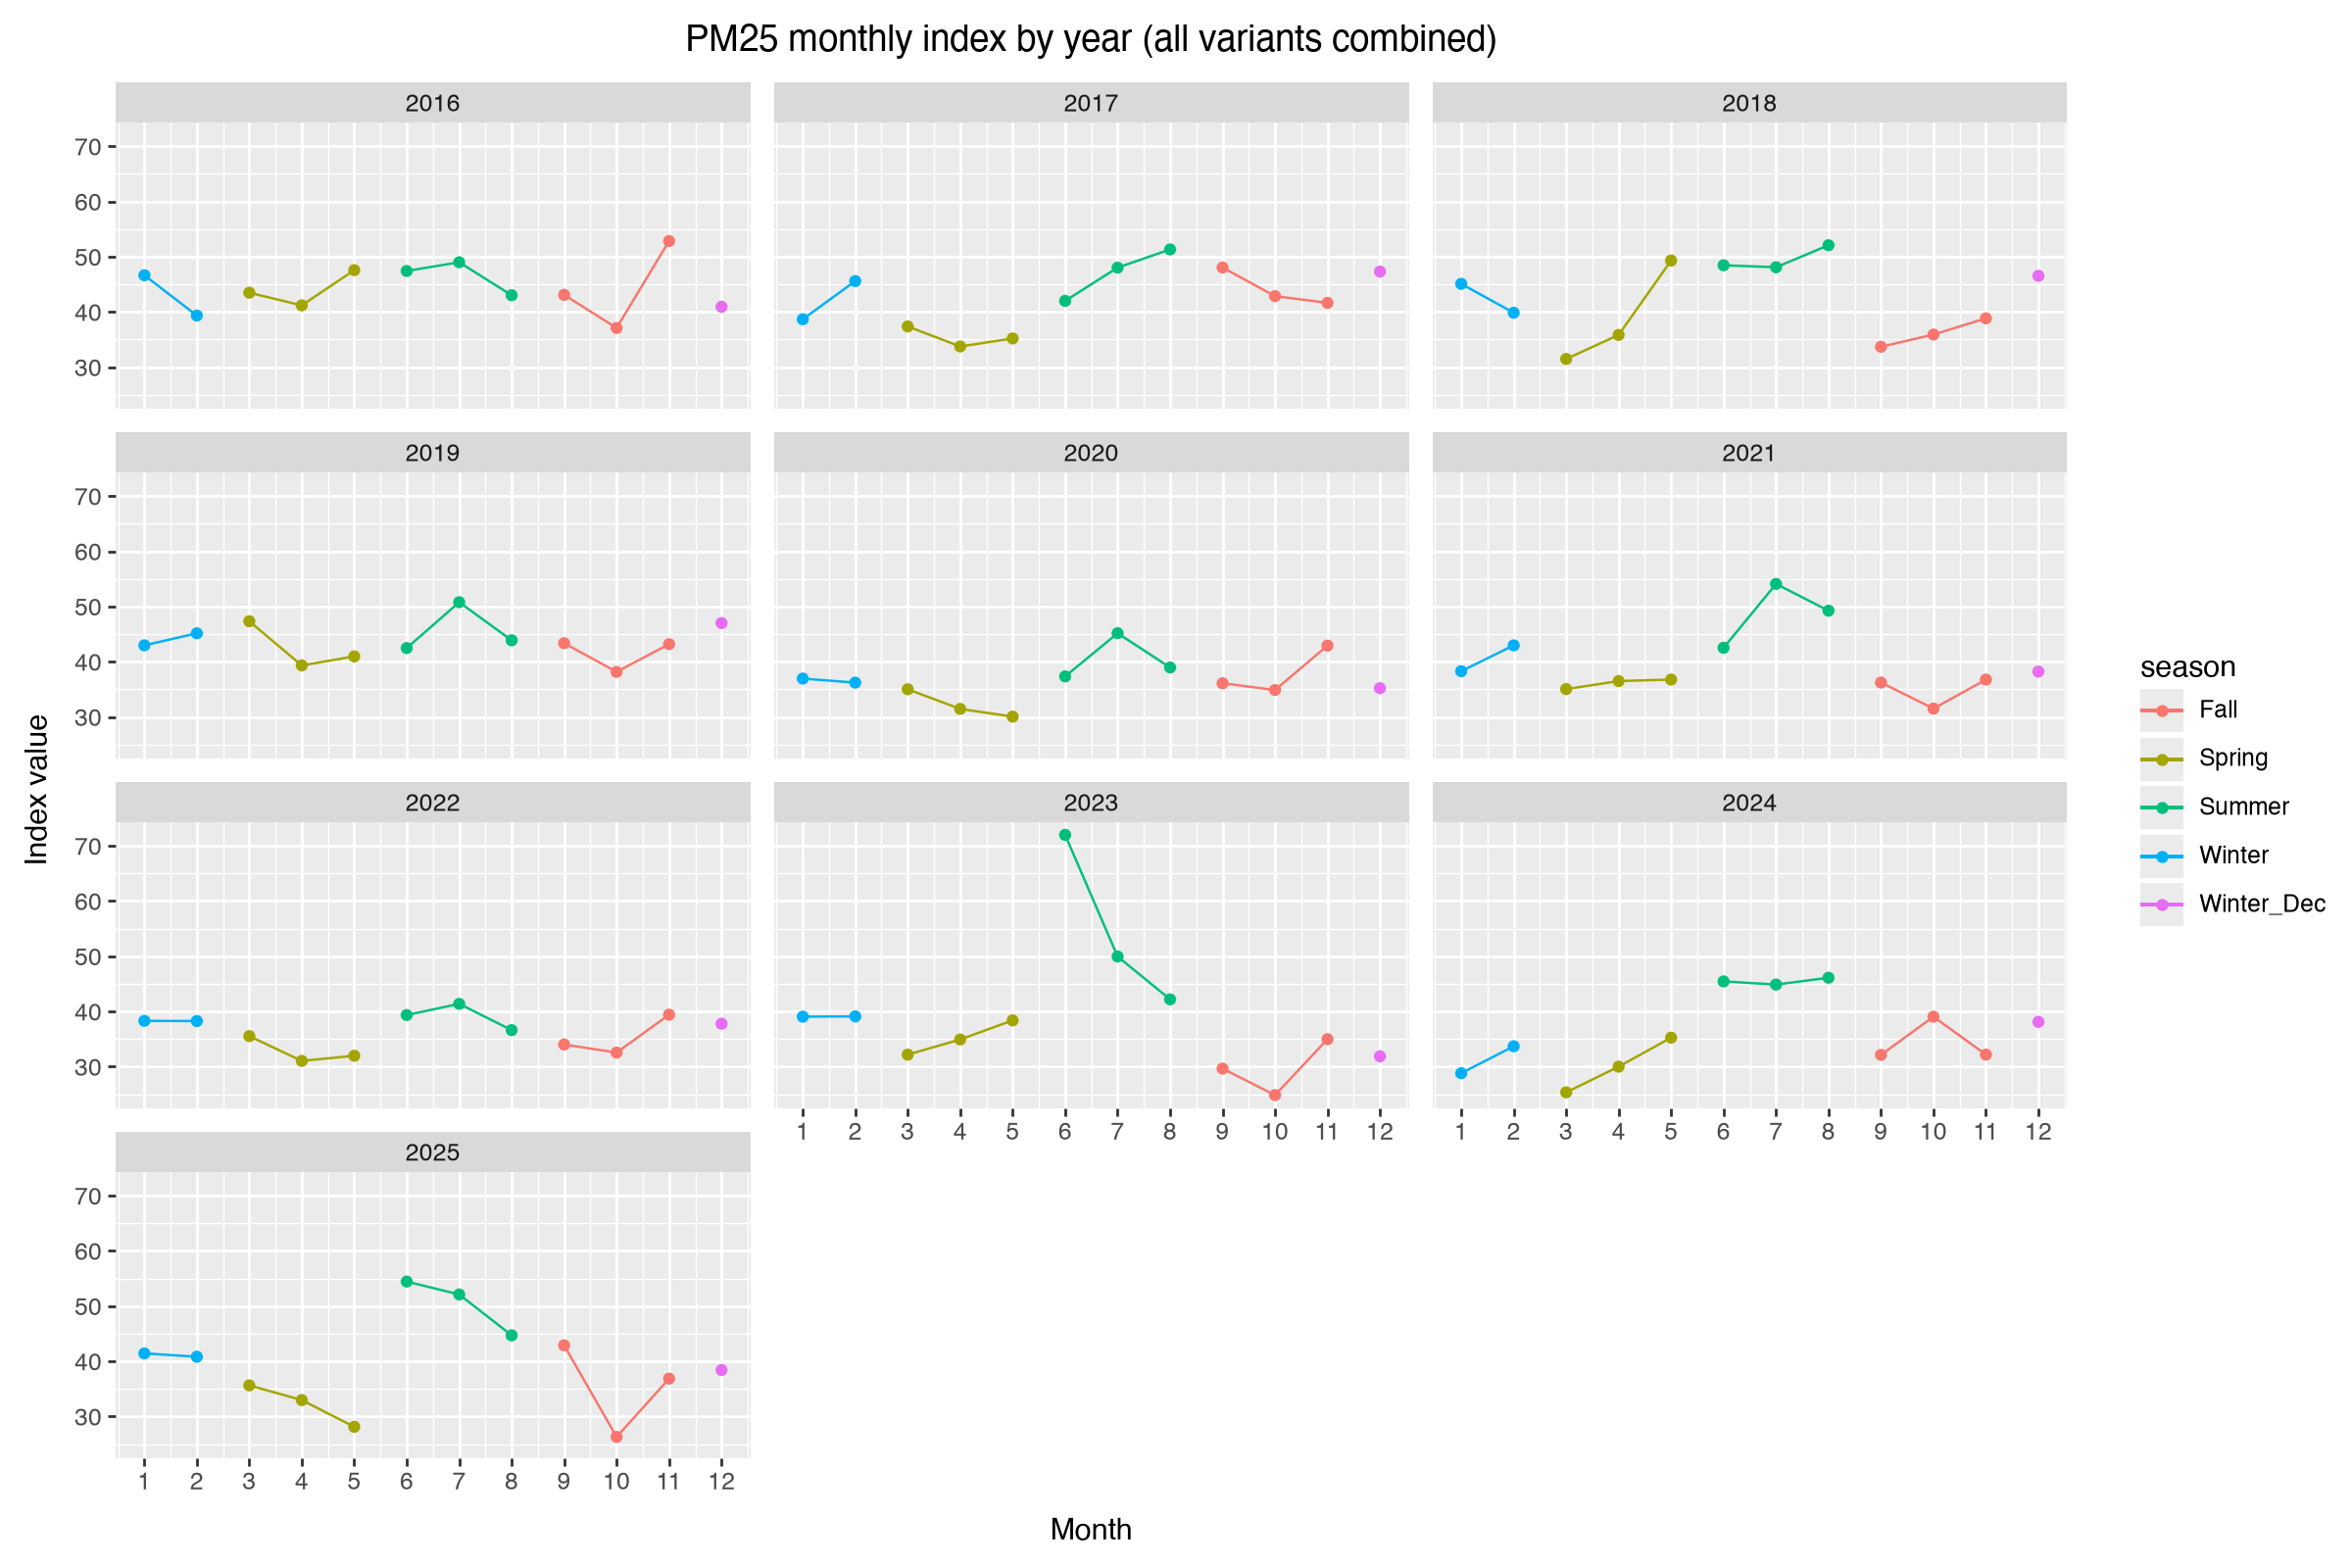

In [68]:
#PM25 TRENDS

(
    ggplot(plot_df_PM25, aes(x='month', y='index_value', color = 'season'))
    + geom_line()
    + geom_point()
    + facet_wrap('~year', ncol=3)
    + scale_x_continuous(breaks=range(1, 13))
    + labs(title='PM25 monthly index by year (all variants combined)',
           x='Month', y='Index value')
    + theme(figure_size=(12, 8))
)

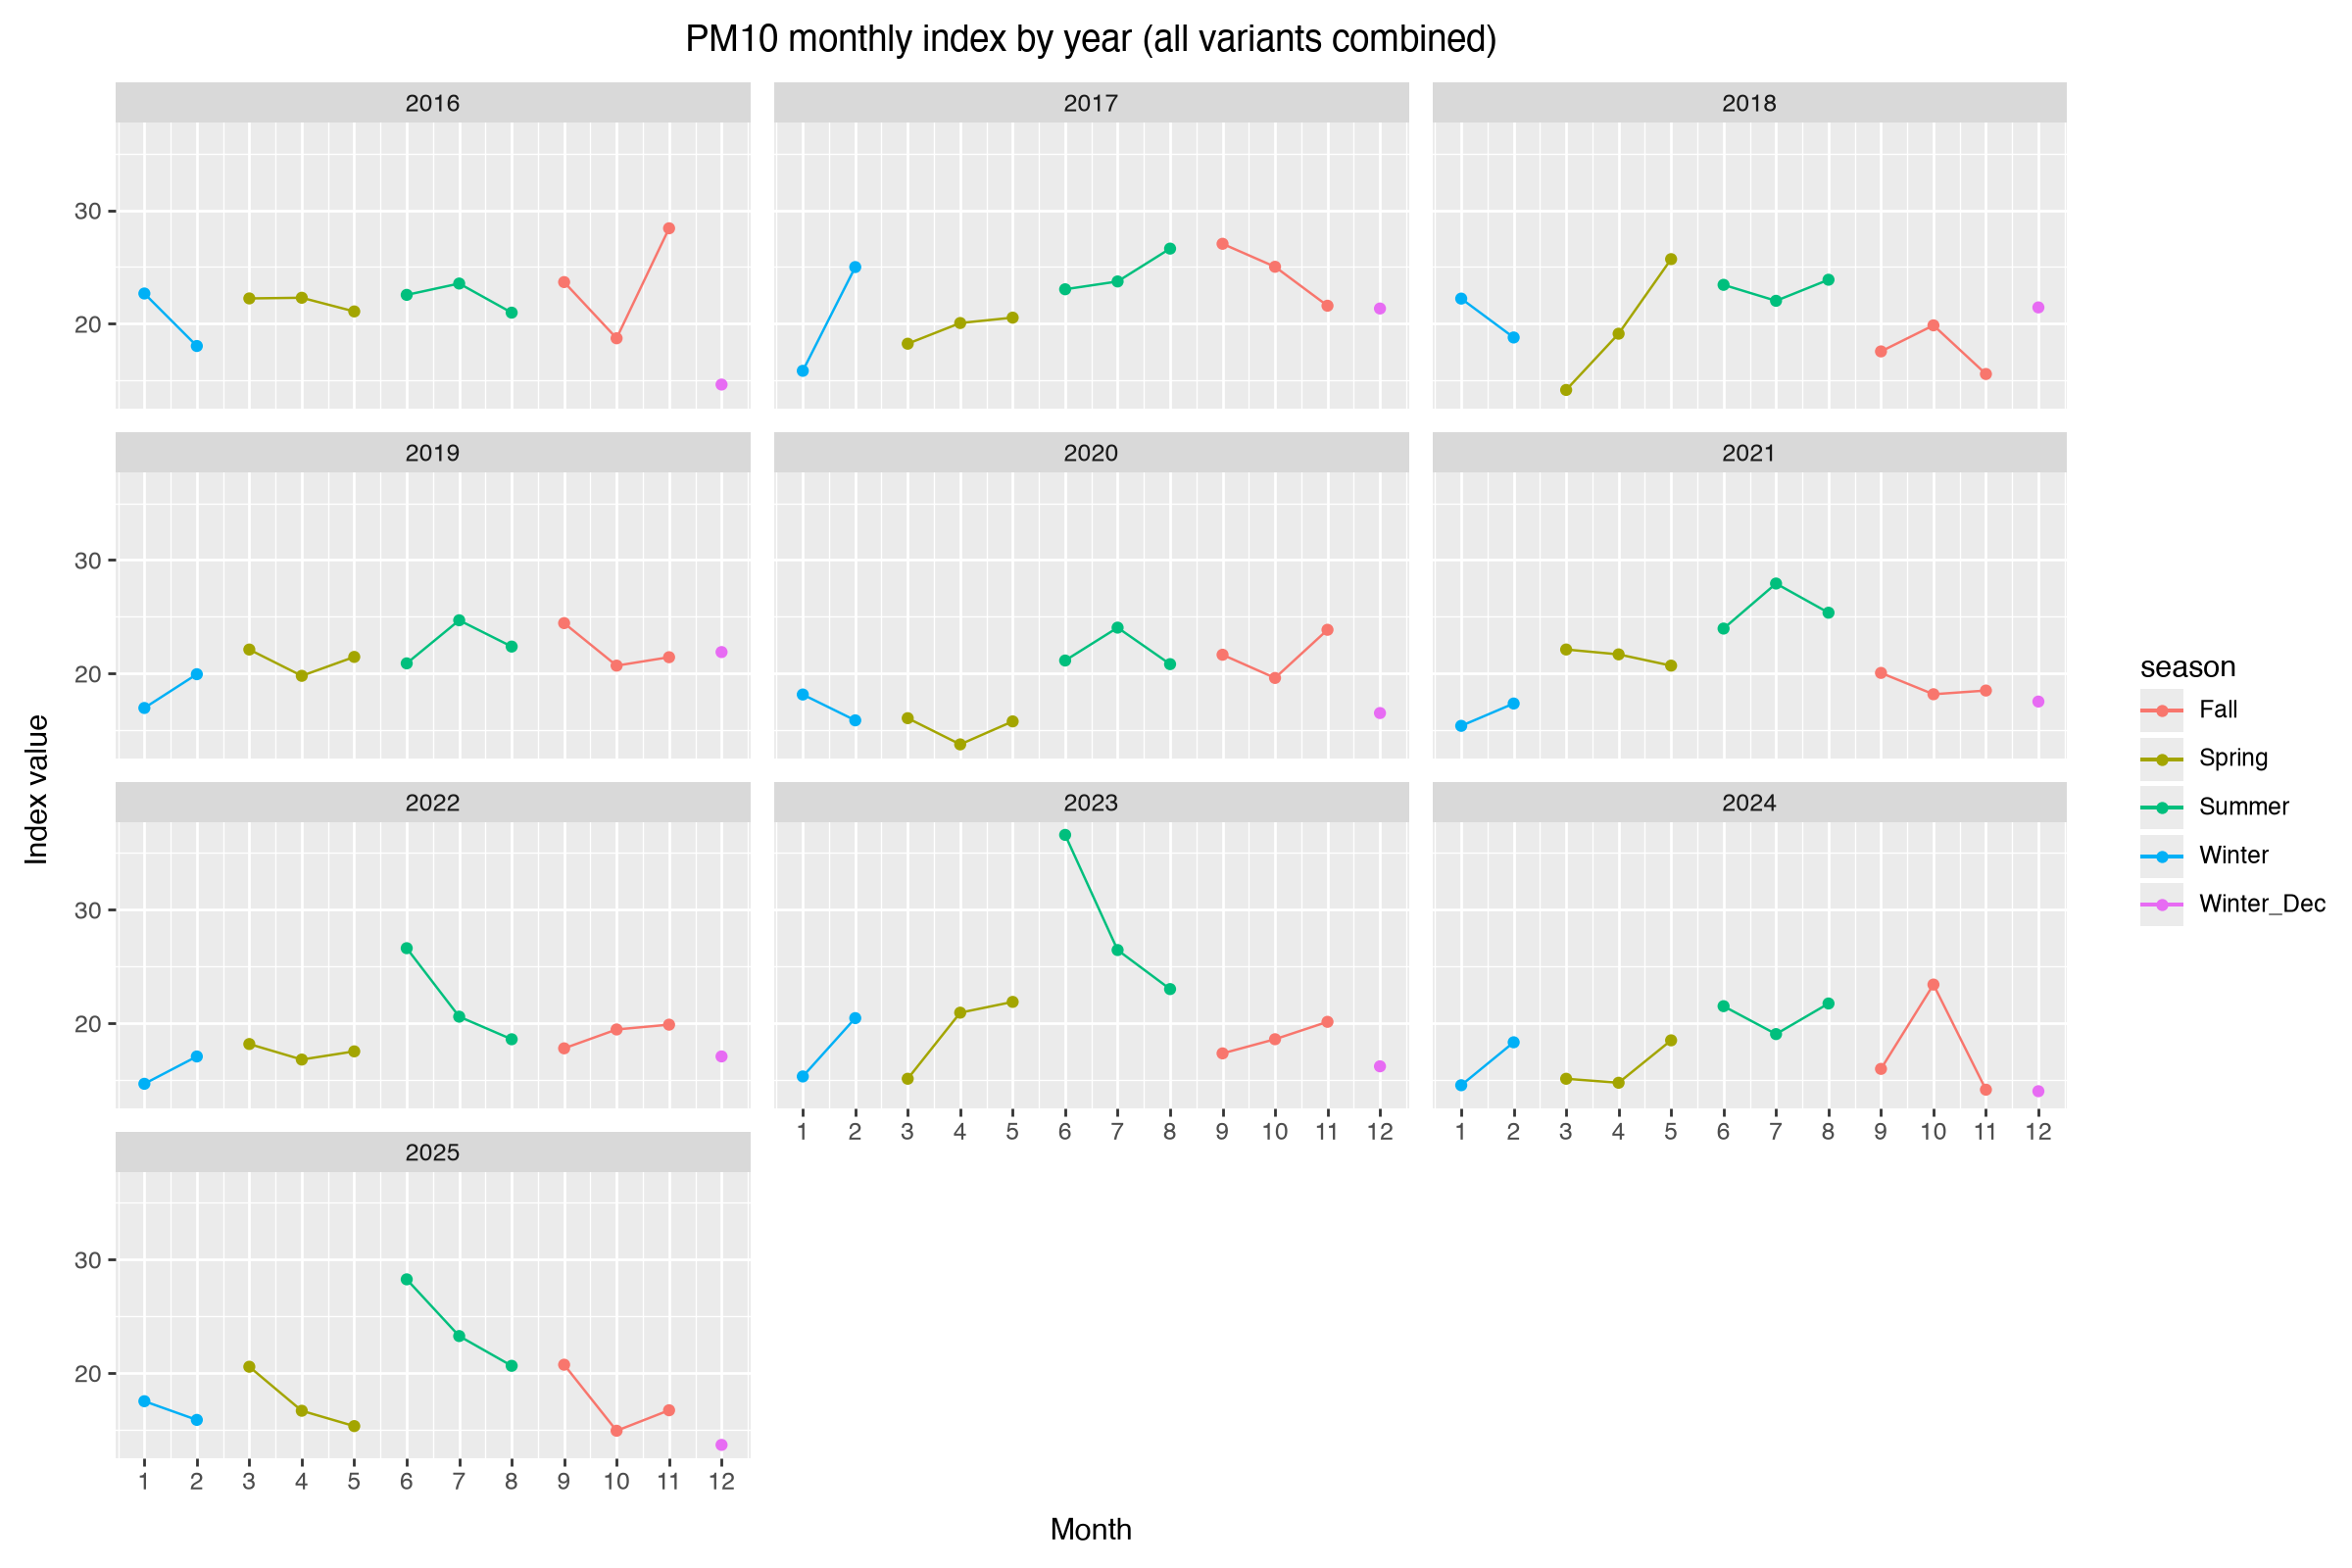

In [69]:
#PM 10 TRENDS
(
    ggplot(plot_df_PM10, aes(x='month', y='index_value', color = 'season'))
    + geom_line()
    + geom_point()
    + facet_wrap('~year', ncol=3)
    + scale_x_continuous(breaks=range(1, 13))
    + labs(title='PM10 monthly index by year (all variants combined)',
           x='Month', y='Index value')
    + theme(figure_size=(12, 8))
)

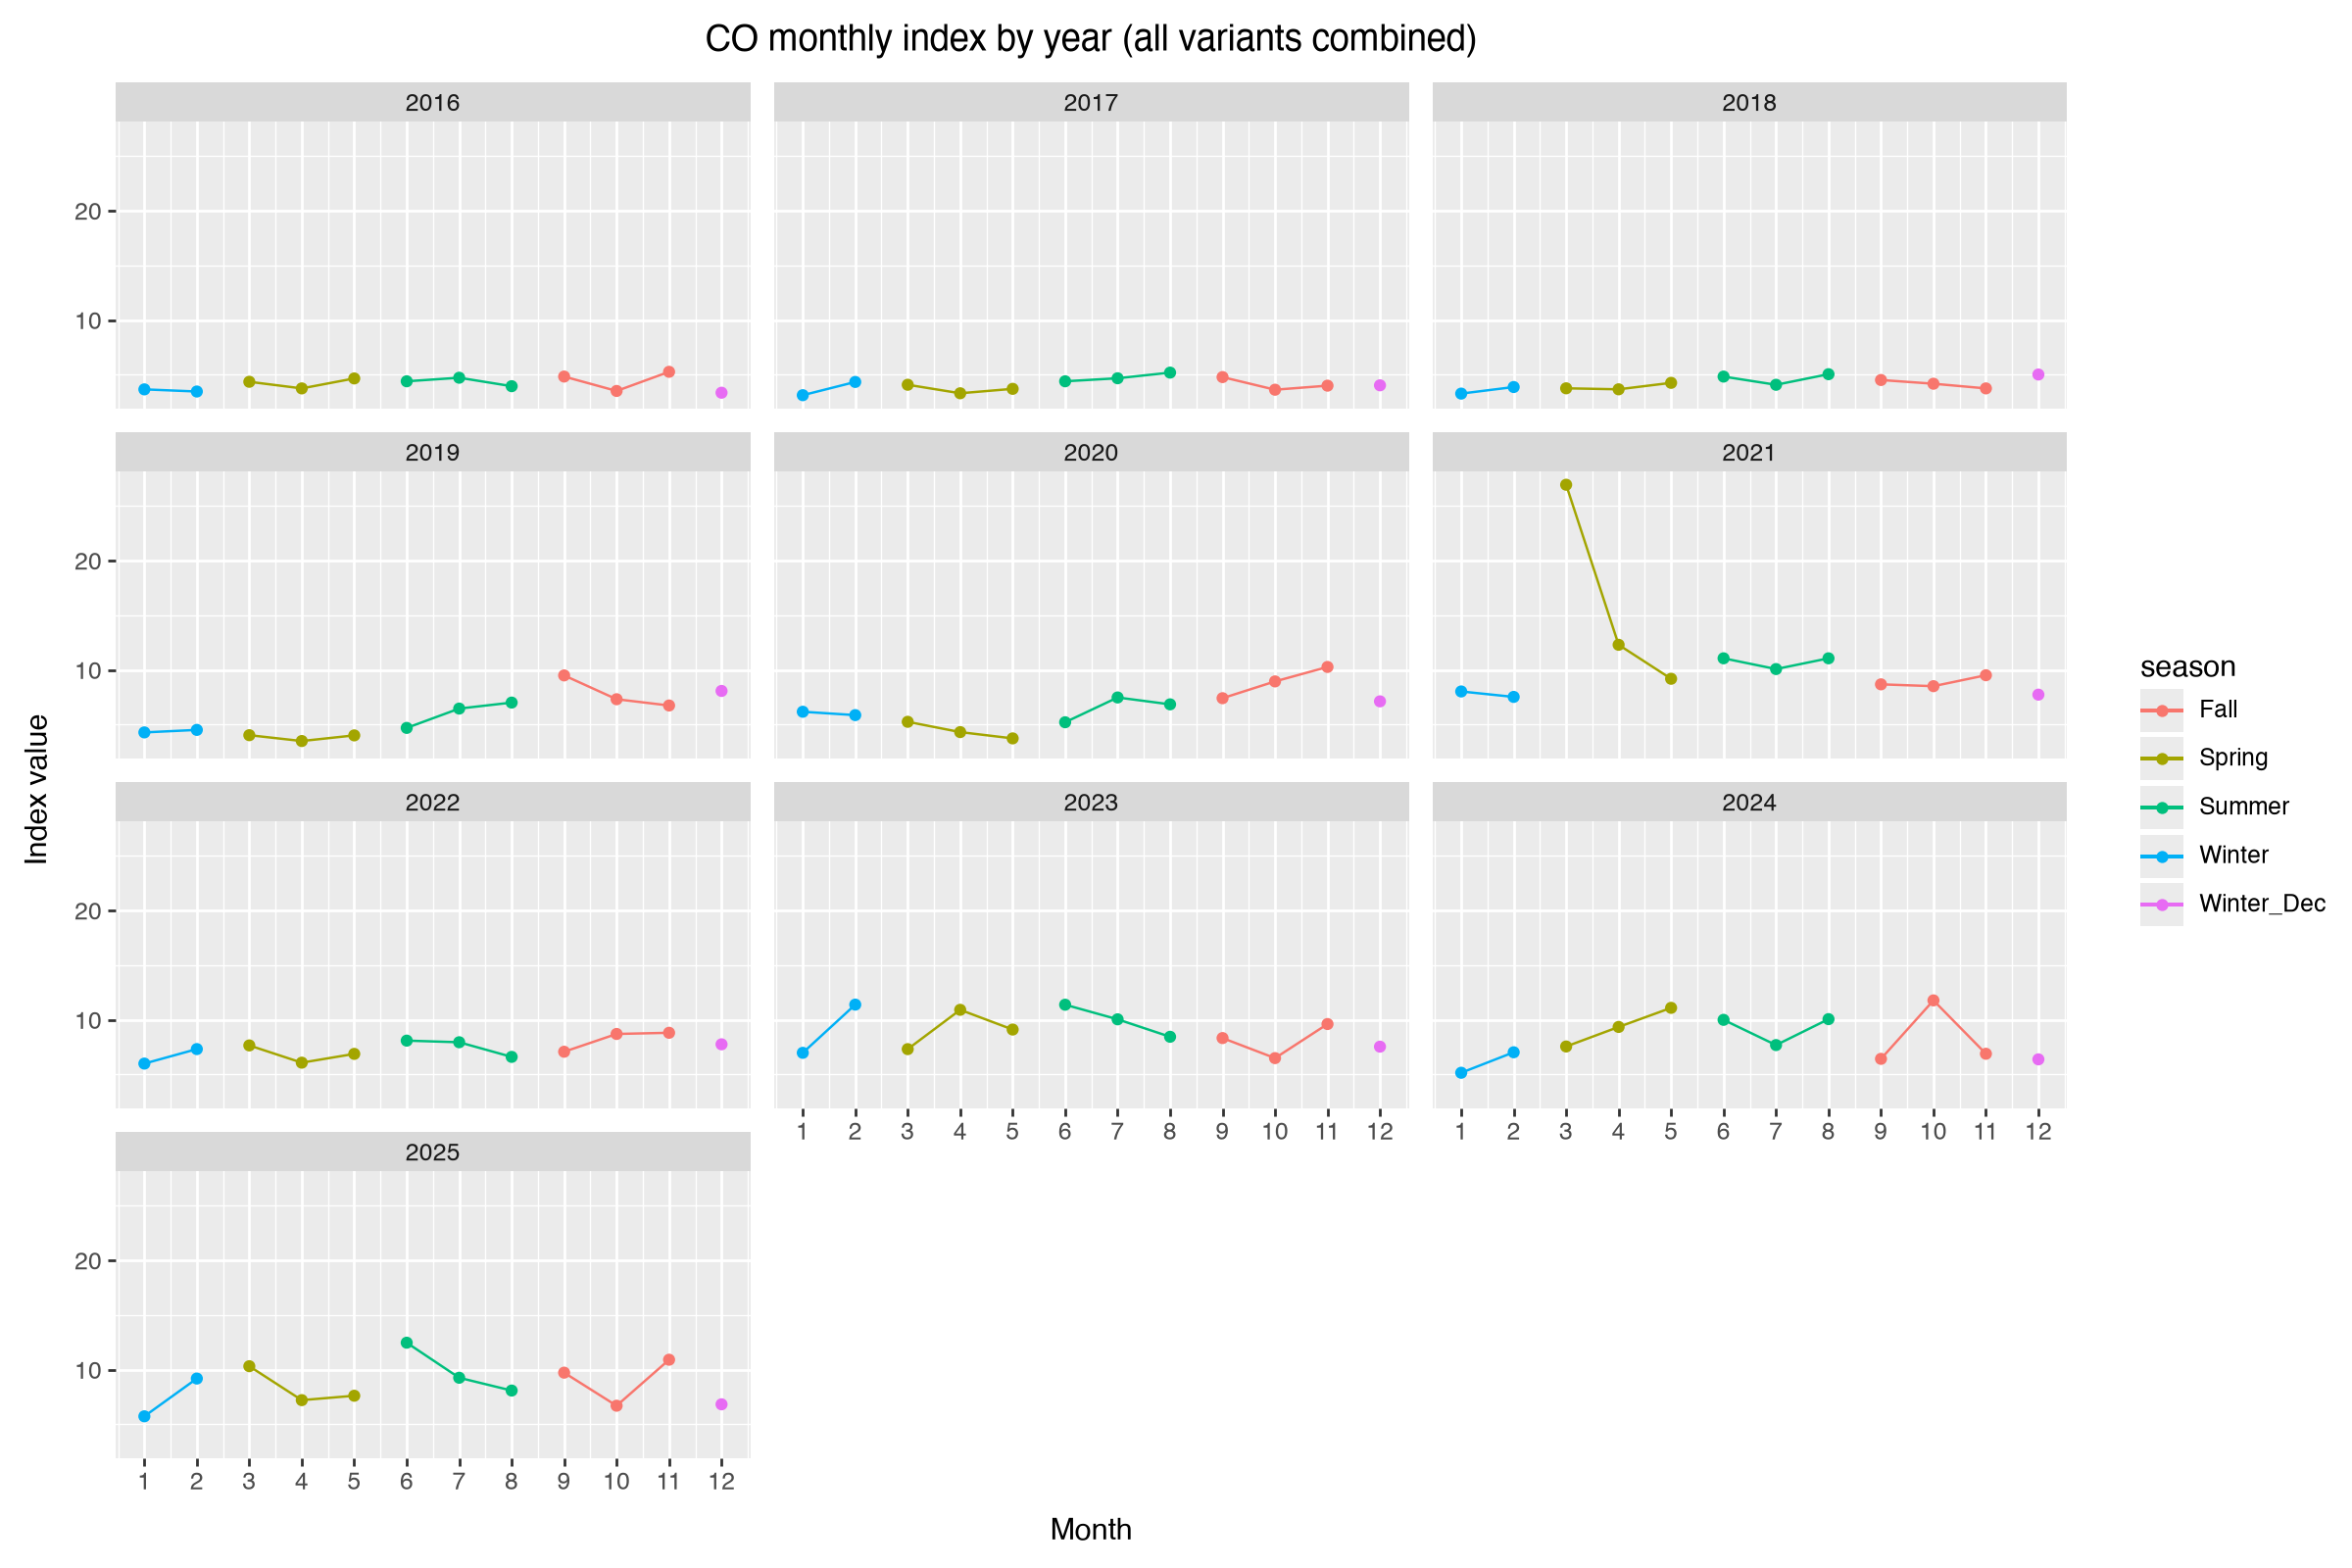

In [70]:
#CO TRENDS
(
    ggplot(plot_df_CO, aes(x='month', y='index_value', color = 'season'))
    + geom_line()
    + geom_point()
    + facet_wrap('~year', ncol=3)
    + scale_x_continuous(breaks=range(1, 13))
    + labs(title='CO monthly index by year (all variants combined)',
           x='Month', y='Index value')
    + theme(figure_size=(12, 8))
)

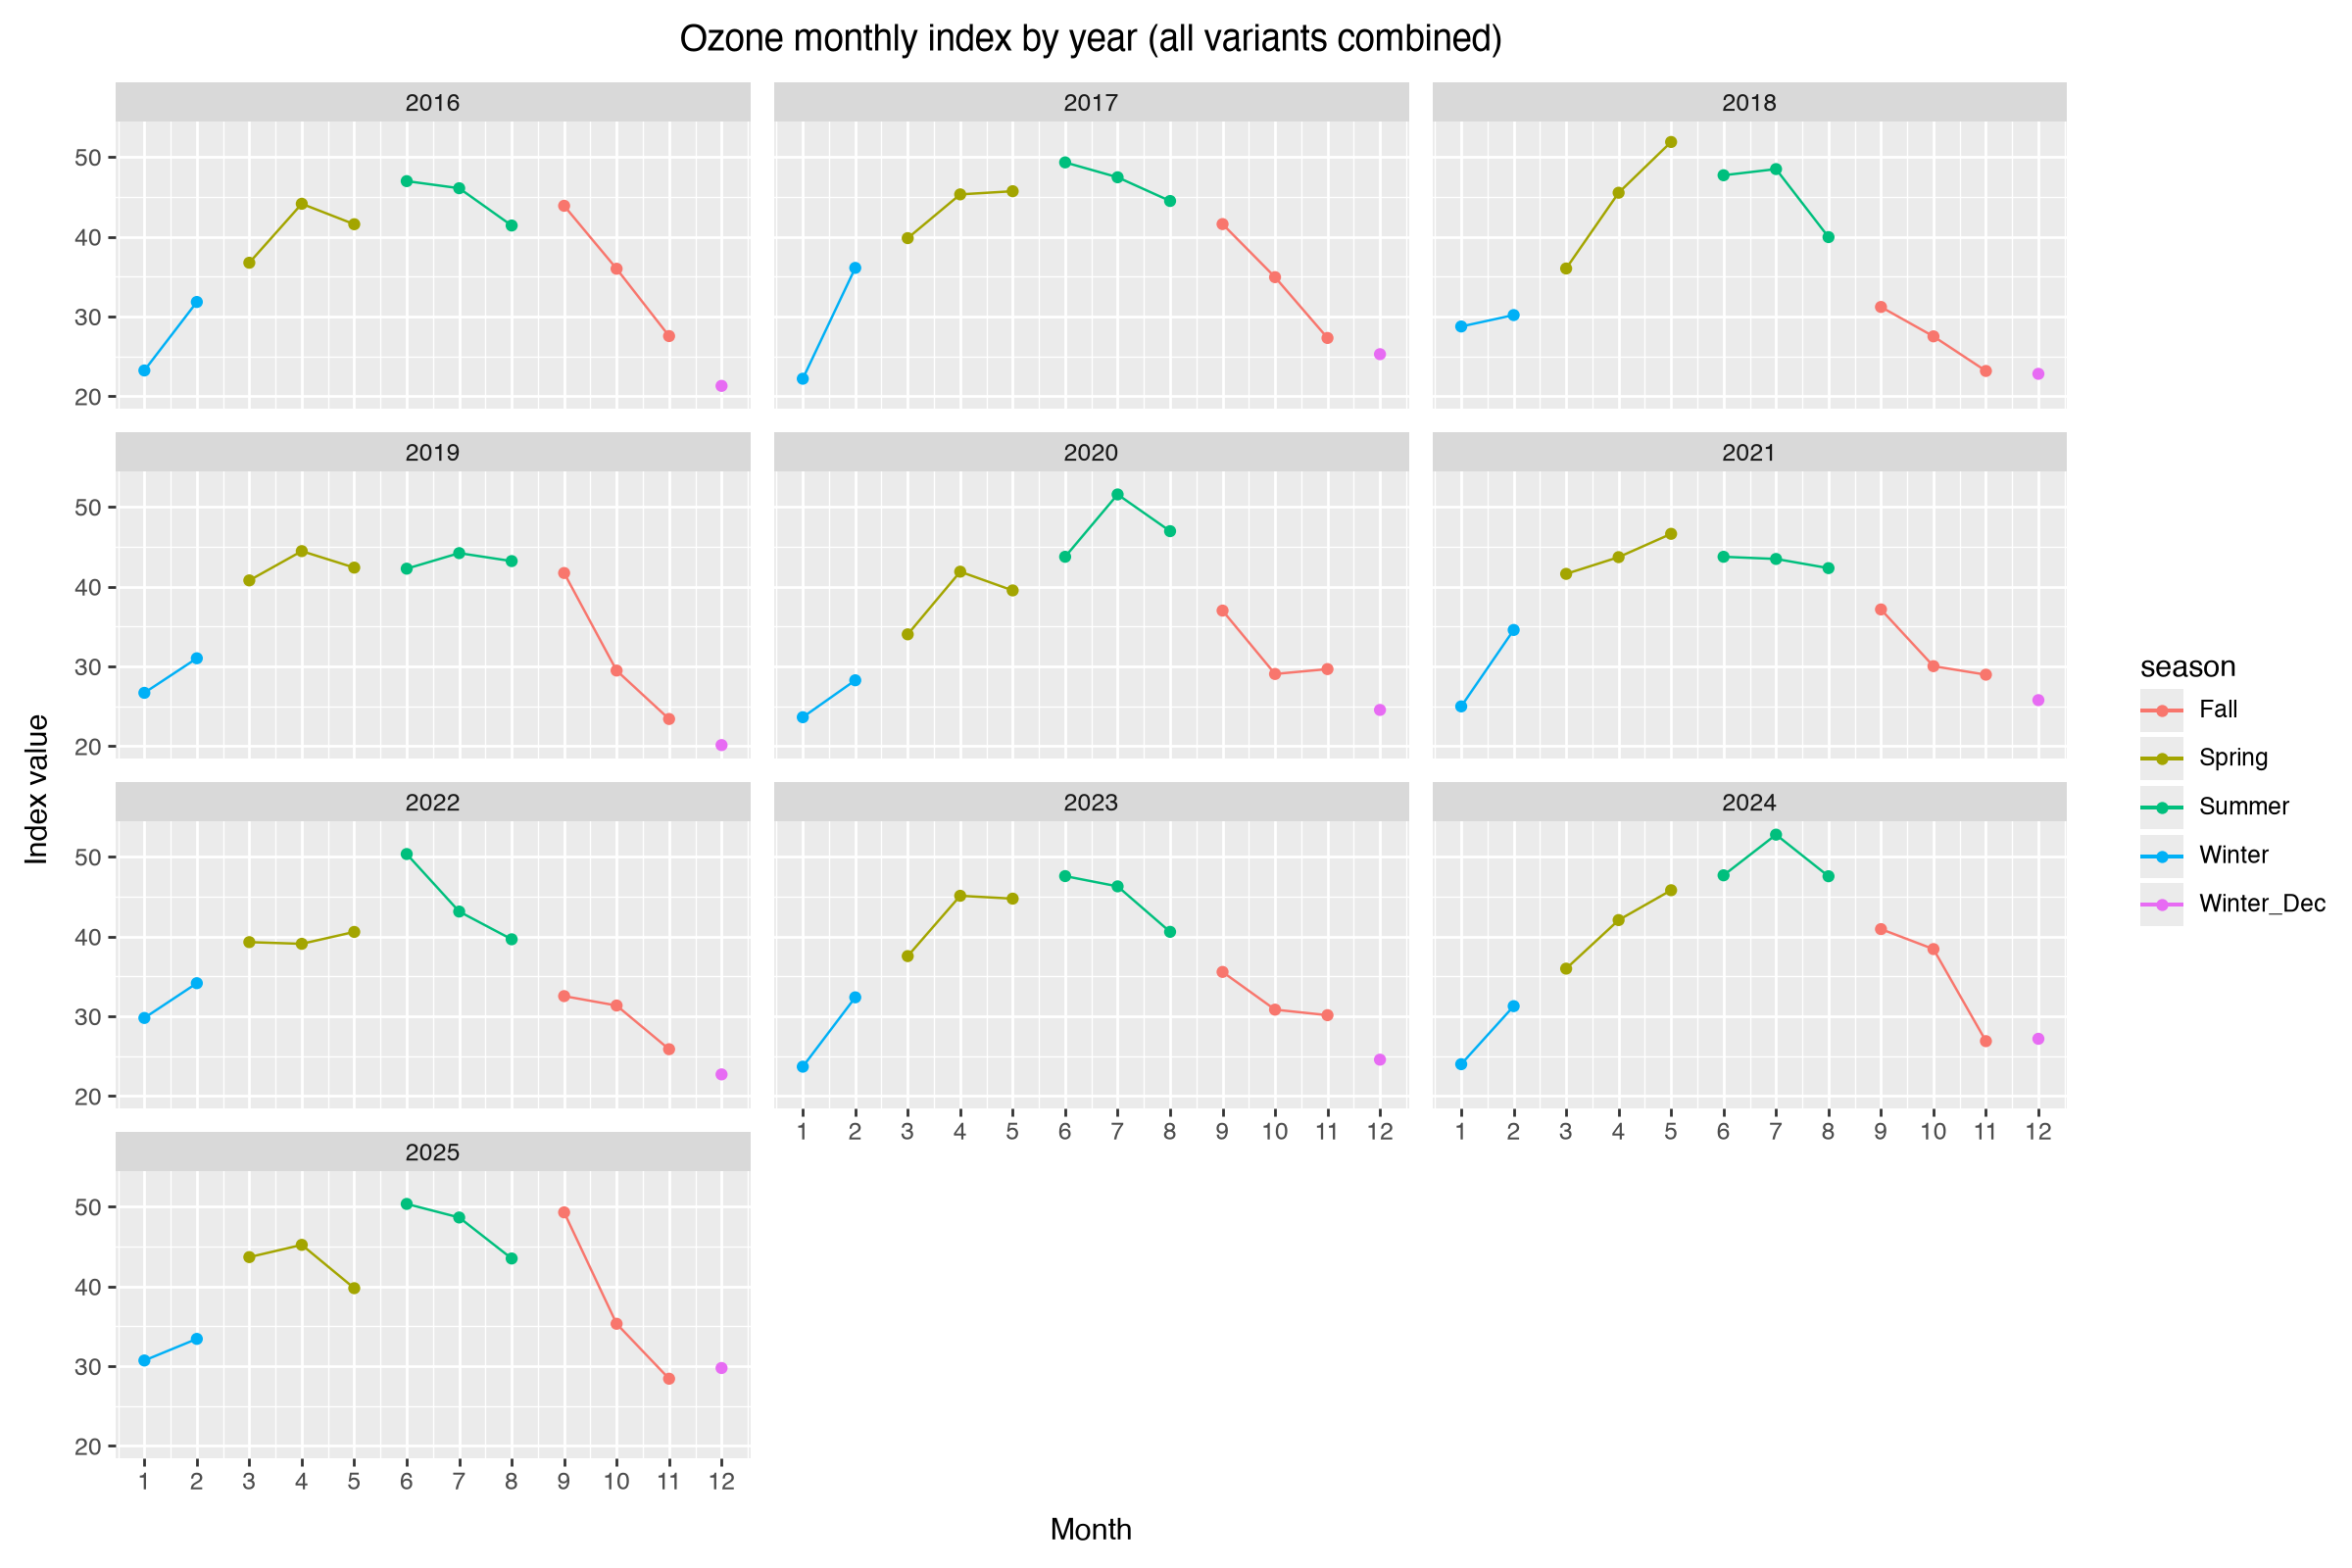

In [71]:
# Ozone TRENDS
(
    ggplot(plot_df_Ozone, aes(x='month', y='index_value', color = 'season'))
    + geom_line()
    + geom_point()
    + facet_wrap('~year', ncol=3)
    + scale_x_continuous(breaks=range(1, 13))
    + labs(title='Ozone monthly index by year (all variants combined)',
           x='Month', y='Index value')
    + theme(figure_size=(12, 8))
)

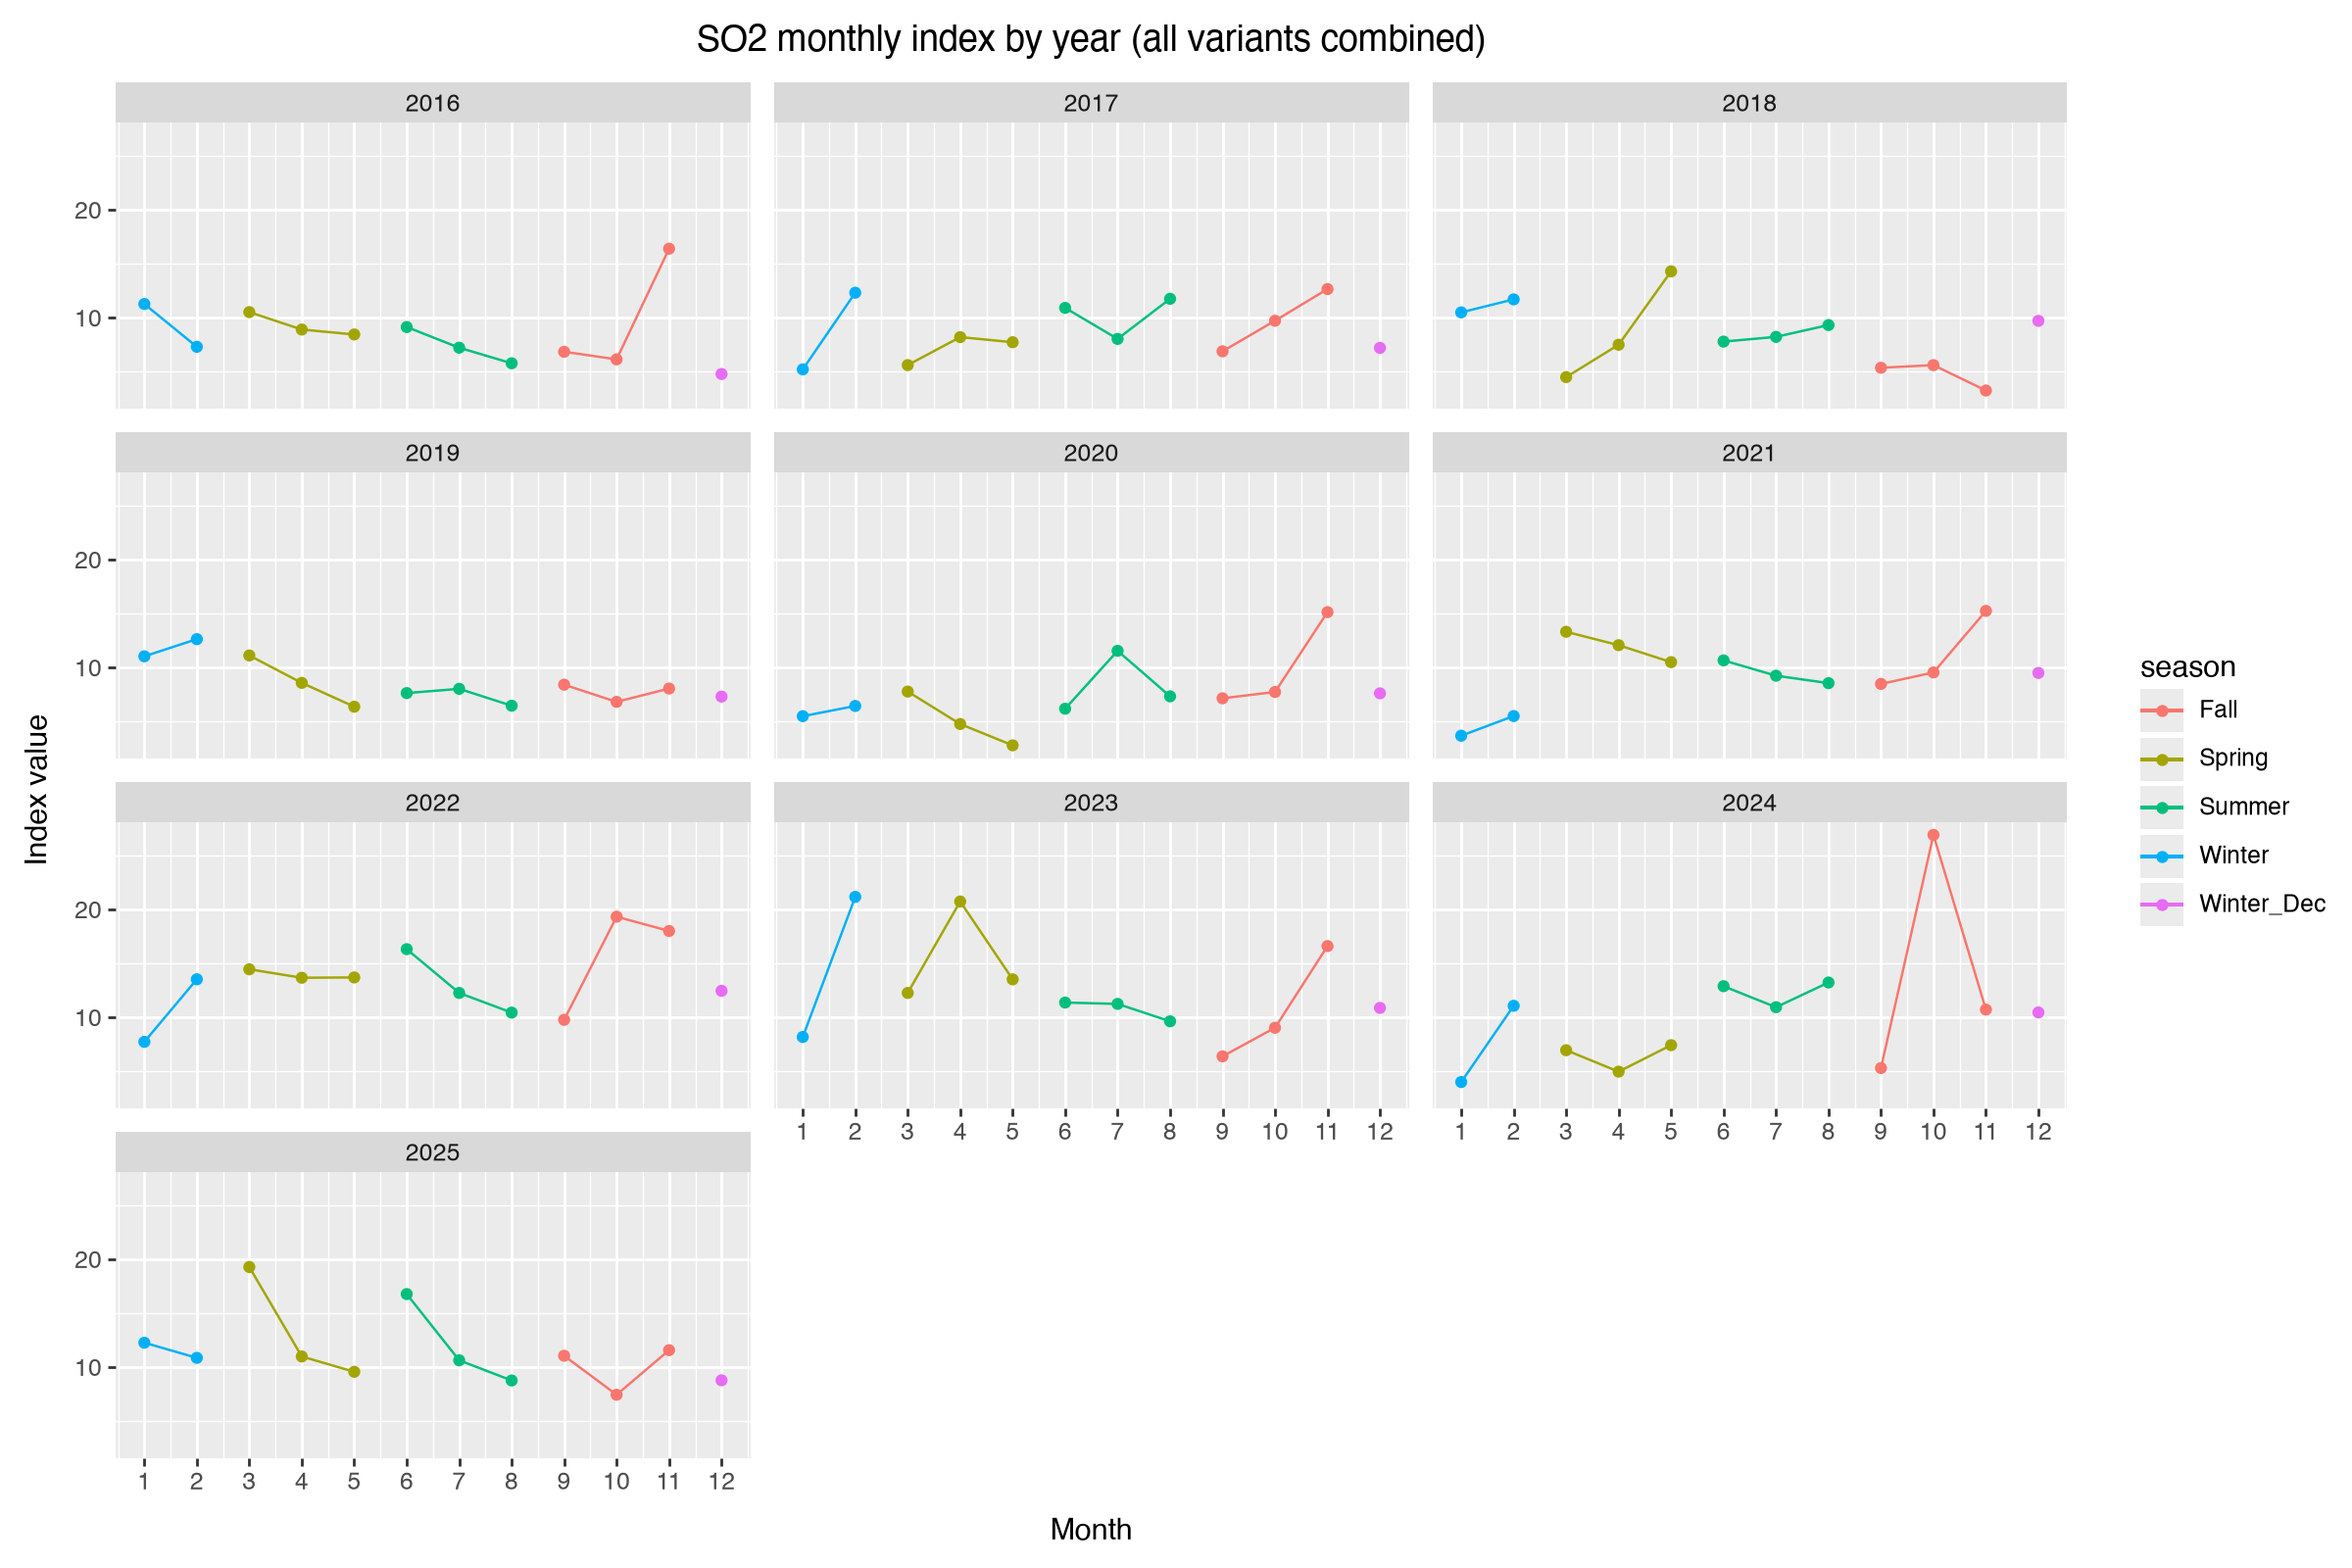

In [72]:
#SO2 TRENDS
(
    ggplot(plot_df_SO2, aes(x='month', y='index_value', color = 'season'))
    + geom_line()
    + geom_point()
    + facet_wrap('~year', ncol=3)
    + scale_x_continuous(breaks=range(1, 13))
    + labs(title='SO2 monthly index by year (all variants combined)',
           x='Month', y='Index value')
    + theme(figure_size=(12, 8))
)


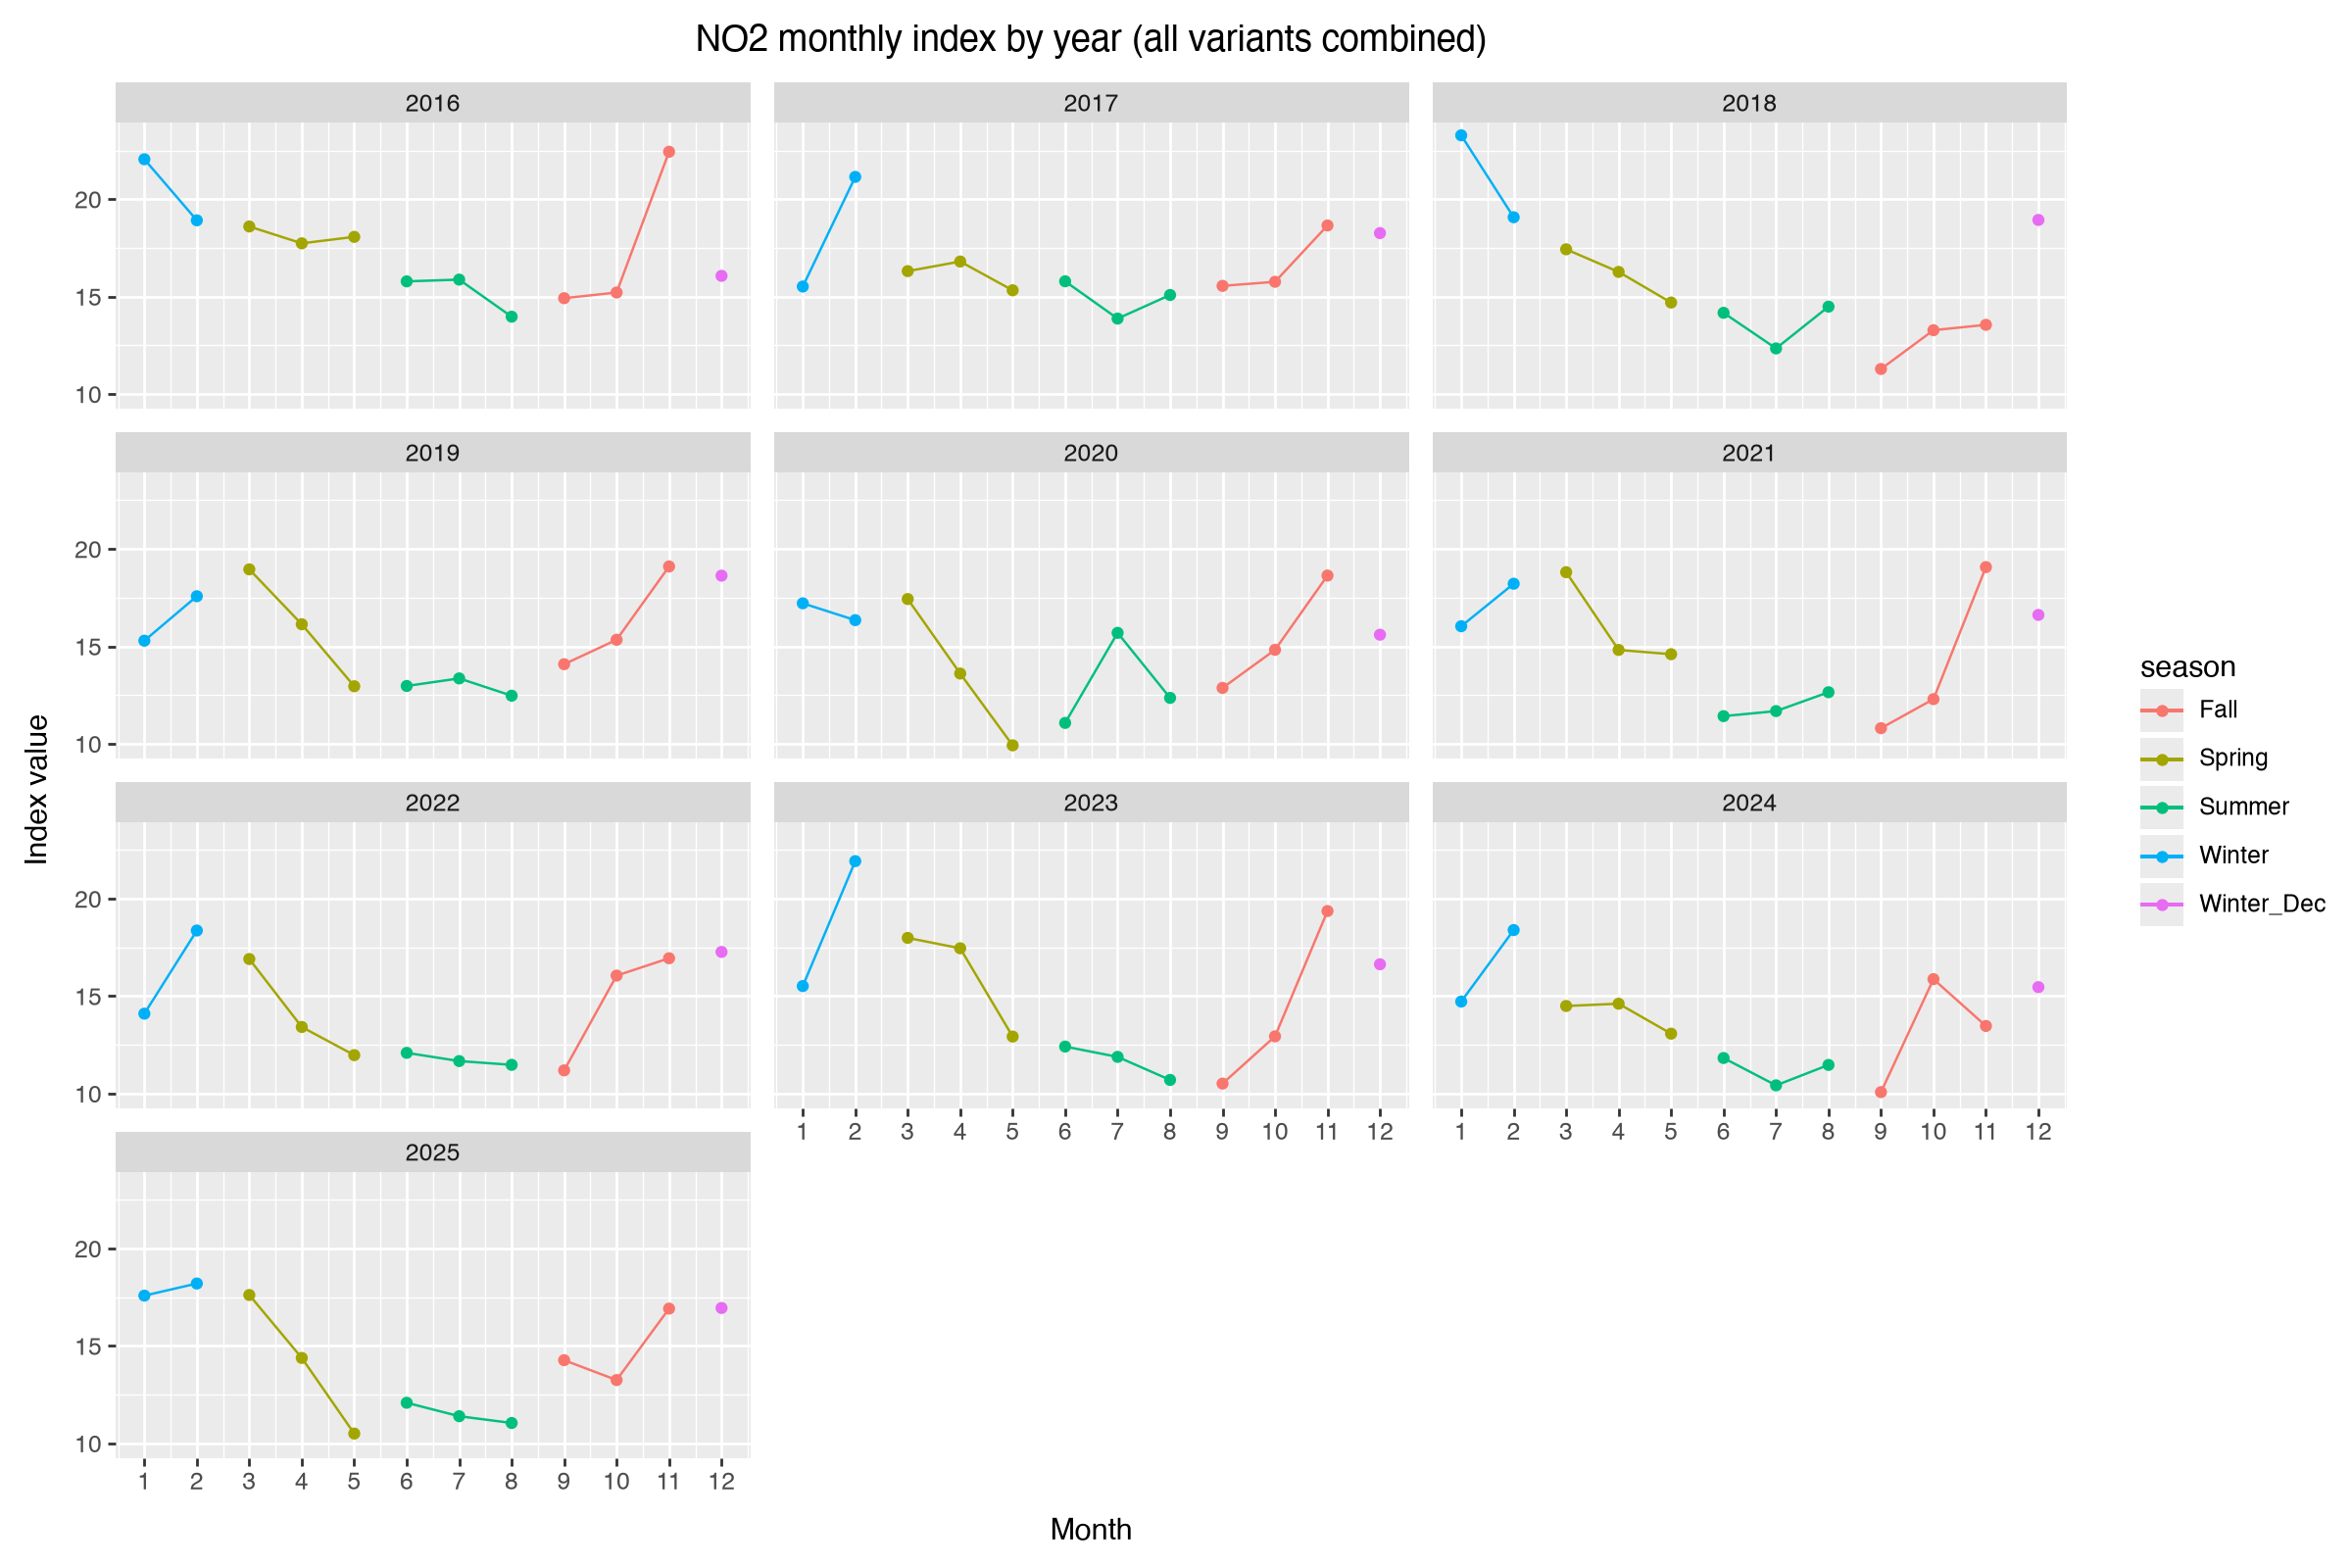

In [73]:
#NO2 TRENDS
(
    ggplot(plot_df_NO2, aes(x='month', y='index_value', color = 'season'))
    + geom_line()
    + geom_point()
    + facet_wrap('~year', ncol=3)
    + scale_x_continuous(breaks=range(1, 13))
    + labs(title='NO2 monthly index by year (all variants combined)',
           x='Month', y='Index value')
    + theme(figure_size=(12, 8))
)

# The Numerical data of the visuals by Pollutant


In [74]:
plot_df_PM25

,date,index_value,year,month,season
0,2016-01-01,46.655914,2016,1,Winter
1,2016-02-01,39.348837,2016,2,Winter
2,2016-03-01,43.488636,2016,3,Spring
3,2016-04-01,41.193182,2016,4,Spring
4,2016-05-01,47.567010,2016,5,Spring
...,...,...,...,...,...
115,2025-08-01,44.698925,2025,8,Summer
116,2025-09-01,42.883333,2025,9,Fall
117,2025-10-01,26.300971,2025,10,Fall
118,2025-11-01,36.854369,2025,11,Fall


In [75]:
plot_df_PM10

,date,index_value,year,month,season
0,2016-01-01,22.661290,2016,1,Winter
1,2016-02-01,18.034483,2016,2,Winter
2,2016-03-01,22.227642,2016,3,Spring
3,2016-04-01,22.285714,2016,4,Spring
4,2016-05-01,21.080645,2016,5,Spring
...,...,...,...,...,...
115,2025-08-01,20.634409,2025,8,Summer
116,2025-09-01,20.733333,2025,9,Fall
117,2025-10-01,14.913043,2025,10,Fall
118,2025-11-01,16.719101,2025,11,Fall


In [76]:
plot_df_CO

,date,index_value,year,month,season
0,2016-01-01,3.661290,2016,1,Winter
1,2016-02-01,3.465517,2016,2,Winter
2,2016-03-01,4.354839,2016,3,Spring
3,2016-04-01,3.750000,2016,4,Spring
4,2016-05-01,4.661290,2016,5,Spring
...,...,...,...,...,...
115,2025-08-01,8.096774,2025,8,Summer
116,2025-09-01,9.733333,2025,9,Fall
117,2025-10-01,6.709677,2025,10,Fall
118,2025-11-01,10.916667,2025,11,Fall


In [77]:
plot_df_Ozone

,date,index_value,year,month,season
0,2016-01-01,23.229167,2016,1,Winter
1,2016-02-01,31.813559,2016,2,Winter
2,2016-03-01,36.731183,2016,3,Spring
3,2016-04-01,44.122222,2016,4,Spring
4,2016-05-01,41.559140,2016,5,Spring
...,...,...,...,...,...
115,2025-08-01,43.494624,2025,8,Summer
116,2025-09-01,49.277778,2025,9,Fall
117,2025-10-01,35.311828,2025,10,Fall
118,2025-11-01,28.422222,2025,11,Fall


In [78]:
plot_df_SO2

,date,index_value,year,month,season
0,2016-01-01,11.258065,2016,1,Winter
1,2016-02-01,7.293103,2016,2,Winter
2,2016-03-01,10.508065,2016,3,Spring
3,2016-04-01,8.891667,2016,4,Spring
4,2016-05-01,8.435484,2016,5,Spring
...,...,...,...,...,...
115,2025-08-01,8.741935,2025,8,Summer
116,2025-09-01,11.033333,2025,9,Fall
117,2025-10-01,7.419355,2025,10,Fall
118,2025-11-01,11.550000,2025,11,Fall


In [79]:
plot_df_NO2

,date,index_value,year,month,season
0,2016-01-01,22.048387,2016,1,Winter
1,2016-02-01,18.913793,2016,2,Winter
2,2016-03-01,18.596774,2016,3,Spring
3,2016-04-01,17.733333,2016,4,Spring
4,2016-05-01,18.064516,2016,5,Spring
...,...,...,...,...,...
115,2025-08-01,11.043011,2025,8,Summer
116,2025-09-01,14.266667,2025,9,Fall
117,2025-10-01,13.247312,2025,10,Fall
118,2025-11-01,16.914634,2025,11,Fall


In [ ]:
# Final reference of original dataframe
df_airquality

,_id,date,site,parameter,index_value,description,health_advisory,health_effects,month,month_name,pollutant_dic
0,1,2016-01-01,Lawrenceville,PM25B,25,Good,NaN,NaN,1,January,PM25
1,2,2016-01-01,Flag Plaza,CO,0,Good,NaN,NaN,1,January,CO
2,3,2016-01-01,Harrison Township,OZONE,31,Good,NaN,NaN,1,January,Ozone
3,4,2016-01-01,Avalon,SO2,10,Good,NaN,NaN,1,January,SO2
4,5,2016-01-01,Lincoln,PM25,35,Good,NaN,NaN,1,January,PM25
...,...,...,...,...,...,...,...,...,...,...,...
80725,97534,2025-12-31,Parkway East,PM25_640,33,Good,NaN,NaN,12,December,PM25
80726,97535,2025-12-31,Pittsburgh,PM25_640,32,Good,NaN,NaN,12,December,PM25
80727,97536,2025-12-31,South Fayette,PM25_640,29,Good,NaN,NaN,12,December,PM25
80729,97538,2025-12-31,Liberty,SO2,4,Good,NaN,NaN,12,December,SO2
